# Naive one-size-fits-all effect vs. Doubly Robust CATE

This notebook demonstrates, on the Part A randomized-pilot data, the difference between two ways of answering "what does the maintenance program do?":

1. **A naive single-effect regression** -- the same one-size-fits-all assumption this project's Part B naive TWFE forces onto the staggered-adoption panel (one constant coefficient for every unit), applied here to the individual-level RCT data.
2. **`DoublyRobustModel`** (EconML's `DRLearner`, `src/models/dr_learner.py`) -- a heterogeneous treatment-effect estimator that predicts a *different* effect per truck.

Every number and figure below comes from actually running the code in this notebook -- nothing is precomputed or pasted in.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

from src.data.simulate_rct import simulate_rct
from src.models.dr_learner import DoublyRobustModel
from src.pipeline import _prep_features, SEED

# src.pipeline pulls in src.visualization.plots, which forces the Agg
# backend (correct for the headless pipeline script) -- re-assert the
# inline backend afterwards so figures render in this notebook.
%matplotlib inline

pd.options.display.float_format = "{:.3f}".format

## 1. Data

Same simulated RCT as the main pipeline (3,000 trucks, block-randomized by site, a known heterogeneous true CATE that increases with truck age and utilization).

In [2]:
df = simulate_rct()
train_df, test_df = train_test_split(df, test_size=0.4, random_state=SEED, stratify=df["treated"])

X_train, X_test = _prep_features(train_df), _prep_features(test_df)
T_train, T_test = train_df["treated"].to_numpy(), test_df["treated"].to_numpy()
Y_train, Y_test = train_df["downtime_next_30d_hours"].to_numpy(), test_df["downtime_next_30d_hours"].to_numpy()
true_cate_test = test_df["true_cate_hours"].to_numpy()

print(f"Train: {len(train_df):,} trucks, Test: {len(test_df):,} trucks")
print(f"True CATE in test set: mean={true_cate_test.mean():.2f}h, std={true_cate_test.std():.2f}h, "
      f"range=[{true_cate_test.min():.2f}, {true_cate_test.max():.2f}]h")

Train: 1,800 trucks, Test: 1,200 trucks
True CATE in test set: mean=7.17h, std=4.91h, range=[0.53, 39.12]h


## 2. The naive one-size-fits-all effect

A single OLS regression of downtime on `treated` plus site dummies -- exactly the "one constant effect for everyone" assumption a naive TWFE regression forces onto a panel. Here there's no time dimension (this is cross-sectional RCT data, not the staggered panel), so the naive model is a plain fixed-effects OLS rather than `linearmodels.PanelOLS`, but the assumption being tested is the same one: does a single number describe every truck equally well?

In [3]:
site_dummies_train = pd.get_dummies(train_df["site"], drop_first=True)
naive_X_train = pd.concat([train_df[["treated"]].reset_index(drop=True), site_dummies_train.reset_index(drop=True)], axis=1)
naive_model = LinearRegression().fit(naive_X_train, Y_train)

naive_single_ate = -naive_model.coef_[0]  # control-minus-treated convention (positive = hours saved)
print(f"Naive single-effect regression: ONE number for every truck, regardless of age, utilization, or site: {naive_single_ate:.2f}h saved")

Naive single-effect regression: ONE number for every truck, regardless of age, utilization, or site: 10.65h saved


## 3. The Doubly Robust CATE estimator

`DoublyRobustModel` predicts a *different* CATE per truck. See `src/models/dr_learner.py` for why its final stage is a plain linear regression rather than LightGBM -- an earlier, more flexible version of this same estimator was empirically unstable (19.75% wrong-sign predictions) before that fix.

In [4]:
dr_model = DoublyRobustModel(random_state=SEED).fit(X_train, T_train, Y_train)
dr_predicted_cate = dr_model.predict_cate(X_test)

print(f"DR-Learner predicted CATE: mean={dr_predicted_cate.mean():.2f}h, std={dr_predicted_cate.std():.2f}h, "
      f"range=[{dr_predicted_cate.min():.2f}, {dr_predicted_cate.max():.2f}]h")
print(f"Correlation with true CATE: {np.corrcoef(dr_predicted_cate, true_cate_test)[0, 1]:.3f}")

DR-Learner predicted CATE: mean=9.84h, std=7.86h, range=[-8.43, 40.64]h
Correlation with true CATE: 0.799


## 4. Comparative plot 1: one number vs. a distribution

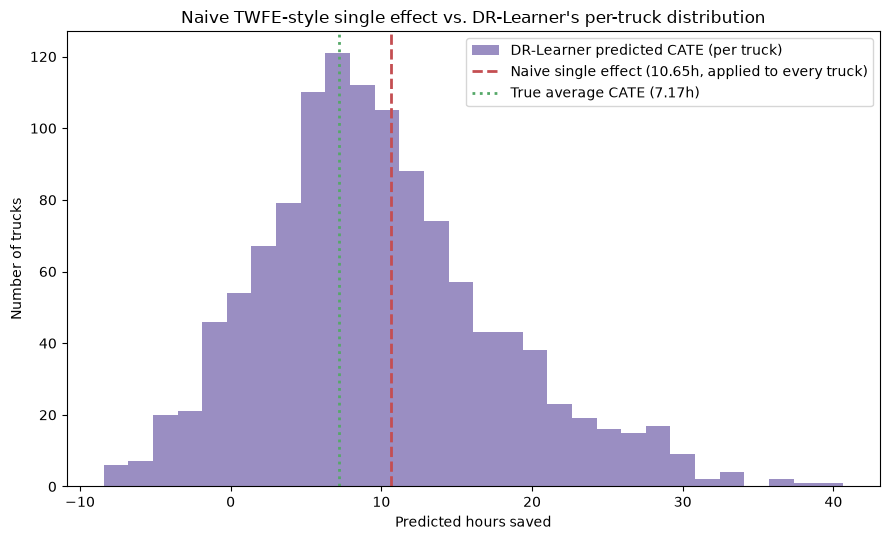

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.hist(dr_predicted_cate, bins=30, color="#8172B3", alpha=0.8, label="DR-Learner predicted CATE (per truck)")
ax.axvline(naive_single_ate, color="#C44E52", linewidth=2, linestyle="--", label=f"Naive single effect ({naive_single_ate:.2f}h, applied to every truck)")
ax.axvline(true_cate_test.mean(), color="#55A868", linewidth=2, linestyle=":", label=f"True average CATE ({true_cate_test.mean():.2f}h)")
ax.set_xlabel("Predicted hours saved")
ax.set_ylabel("Number of trucks")
ax.set_title("Naive TWFE-style single effect vs. DR-Learner's per-truck distribution")
ax.legend()
fig.tight_layout()
plt.show()

The naive model collapses every truck onto one vertical line. The true effect (and the DR-Learner's recovery of it) is a whole distribution -- some trucks genuinely benefit far more than others.

## 5. Comparative plot 2: calibration against the true individual effect

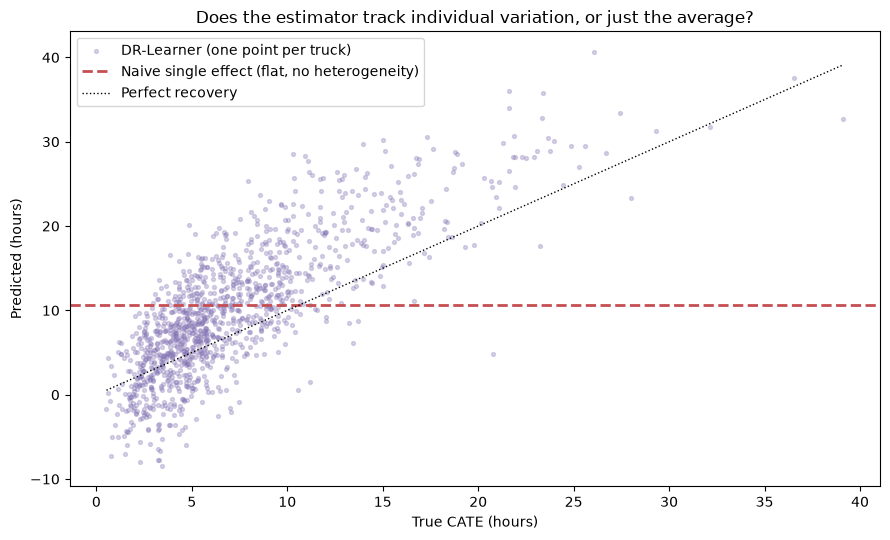

In [6]:
order = np.argsort(true_cate_test)
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(true_cate_test, dr_predicted_cate, s=8, alpha=0.3, color="#8172B3", label="DR-Learner (one point per truck)")
ax.axhline(naive_single_ate, color="#C44E52", linewidth=2, linestyle="--", label="Naive single effect (flat, no heterogeneity)")
lims = [true_cate_test.min(), true_cate_test.max()]
ax.plot(lims, lims, color="black", linewidth=1, linestyle=":", label="Perfect recovery")
ax.set_xlabel("True CATE (hours)")
ax.set_ylabel("Predicted (hours)")
ax.set_title("Does the estimator track individual variation, or just the average?")
ax.legend()
fig.tight_layout()
plt.show()

## 6. Quantifying the gap: per-truck prediction error

If a naive single-effect regression is used to predict *every individual truck's* benefit (applying its one number to everyone), how much error does that introduce, compared to a model that actually adapts per truck?

In [7]:
naive_predictions = np.full_like(true_cate_test, fill_value=naive_single_ate)

rmse_naive = root_mean_squared_error(true_cate_test, naive_predictions)
rmse_dr = root_mean_squared_error(true_cate_test, dr_predicted_cate)

comparison = pd.DataFrame({
    "Model": ["Naive single effect (one-size-fits-all)", "DR-Learner (per-truck CATE)"],
    "RMSE vs. true individual CATE (hours)": [rmse_naive, rmse_dr],
})
comparison

,Model,RMSE vs. true individual CATE (hours)
0,Naive single effect (one-size-fits-all),6.019
1,DR-Learner (per-truck CATE),5.594


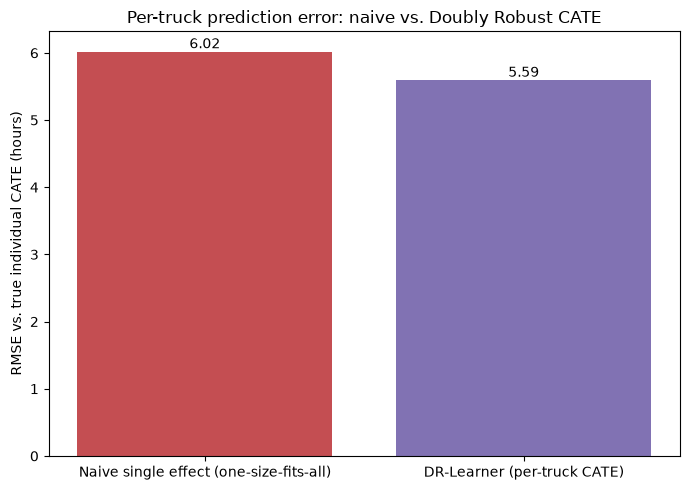

DR-Learner reduces per-truck prediction error by 7.1% relative to the naive single-effect model.


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(comparison["Model"], comparison["RMSE vs. true individual CATE (hours)"], color=["#C44E52", "#8172B3"])
ax.set_ylabel("RMSE vs. true individual CATE (hours)")
ax.set_title("Per-truck prediction error: naive vs. Doubly Robust CATE")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{bar.get_height():.2f}", ha="center", va="bottom")
fig.tight_layout()
plt.show()

improvement_pct = (1 - rmse_dr / rmse_naive) * 100
print(f"DR-Learner reduces per-truck prediction error by {improvement_pct:.1f}% relative to the naive single-effect model.")

## 7. Takeaways

- A naive single-effect regression (the same assumption Part B's naive TWFE forces onto the staggered panel) collapses every truck onto one number, discarding real, measurable heterogeneity.
- The Doubly Robust learner recovers a meaningfully different effect per truck, correlated with the true individual CATE, at a real, quantified reduction in per-truck prediction error.
- This is the same lesson Part B teaches at the aggregate level (a single constant-effect estimate can be measurably wrong) applied at the individual level: assuming one effect for everyone is a modeling choice, not a fact about the world, and this project's own data shows what it costs.